# Anthropic OAuth Policy Change: Impact Analysis

A synthetic data exercise. Mirrors the within-version quality estimator from
[bouldergearlab.com/data-projects/model-quality/](https://bouldergearlab.com/data-projects/model-quality/)
and adapts it to a policy change: Anthropic blocking OAuth access for Pro/Max subscriptions,
forcing users to API keys.

**Structure:**
1. Libraries & setup
2. Parameters
3. Generate user characteristics
4. Pre-policy timeseries & identification
5. Post-policy outcome simulation
6. Difference-in-differences estimator
7. Scenario modeling (High Churn / Base / High Convert)
8. Visualizations & exports


In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(purrr)
library(tibble)
library(stringr)
library(forcats)
library(readr)
library(scales)
library(patchwork)

set.seed(2026)

# Set to the notebook's directory so figures save alongside it.
script_dir <- normalizePath(getwd())
output_dir <- file.path(script_dir, "figures")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

cat("Output directory:", output_dir, "\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


The following object is masked from ‘package:purrr’:

    discard




Output directory: /workspaces/bouldergearlab/content/data-projects/rate-limit/figures 


## Section 1: Parameters

True causal effects are injected into the data-generating process and recovered by the estimator later. Revenue parameters reflect Anthropic's actual pricing at the time of the policy change.

In [2]:
N_USERS     <- 50000
N_WEEKS     <- 26
POLICY_WEEK <- 13   # OAuth block goes live at week 13

# True causal effects injected into the DGP, to be recovered
TRUE_CHURN_HEAVY   <- 0.42   # P(churn | heavy OAuth user, post-policy)
TRUE_CONVERT_HEAVY <- 0.40   # P(convert to API key | heavy OAuth user)
TRUE_BUNDLE_HEAVY  <- 0.18   # P(buy extra bundle | heavy OAuth user)
# Residual ~0% retained on subscription (heavy users lose OAuth, must act)

TRUE_CHURN_LIGHT   <- 0.08   # Light OAuth users mostly unaffected
TRUE_CONVERT_LIGHT <- 0.07
TRUE_BUNDLE_LIGHT  <- 0.04

# Revenue parameters (monthly)
REV_PRO    <- 20
REV_MAX    <- 200
REV_API    <- 85    # average API spend for converted user (pay-as-you-go)
REV_BUNDLE <- 50    # extra usage bundle add-on price
COST_PER_COMPUTE_UNIT <- 8   # internal cost per normalized compute unit

cat("Parameters set. N_USERS =", N_USERS, "| POLICY_WEEK =", POLICY_WEEK, "\n")

Parameters set. N_USERS = 50000 | POLICY_WEEK = 13 


## Section 2: Generate User Characteristics

OAuth intensity is structurally driven by role, not plan tier. Developers use more third-party tooling than Business or Casual users on the same plan — this is the within-plan-tier variation we identify on.

In [3]:
make_oauth <- function(segment, n) {
  case_when(
    segment == "Developer" ~ rbeta(n, 3.0, 1.5),
    segment == "Business"  ~ rbeta(n, 1.8, 2.5),
    segment == "Casual"    ~ rbeta(n, 0.7, 4.0)
  )
}

users <- tibble(
  user_id  = 1:N_USERS,
  segment  = sample(c("Developer", "Business", "Casual"),
                    N_USERS, replace = TRUE, prob = c(0.28, 0.34, 0.38)),
  plan     = sample(c("Pro", "Max"), N_USERS,
                    replace = TRUE, prob = c(0.80, 0.20))
) |>
  mutate(
    oauth_intensity_true = make_oauth(segment, N_USERS),

    # Baseline engagement: probability of being active on any given day
    baseline_engagement = rnorm(N_USERS, mean = 0.57, sd = 0.13) |>
      pmax(0.05) |> pmin(0.97),

    # Monthly subscription revenue
    revenue_pre = if_else(plan == "Max", REV_MAX, REV_PRO),

    # Compute load: heavy OAuth users consume 3-5x more compute
    # because every third-party API call routes through Claude
    compute_load = if_else(
      oauth_intensity_true > 0.5,
      oauth_intensity_true * rnorm(N_USERS, 4.3, 0.9) |> pmax(0.5),
      oauth_intensity_true * rnorm(N_USERS, 1.1, 0.3) |> pmax(0.1)
    ),

    # Cost/revenue ratio, the metric that triggered the decision
    cost_revenue_ratio = (compute_load * COST_PER_COMPUTE_UNIT) / revenue_pre,

    # Binary treatment: heavy OAuth users are "treated" by the policy
    oauth_heavy = oauth_intensity_true > 0.5
  )

cat("===== THE BUSINESS PROBLEM =====\n")
cat("Cost/Revenue Ratio by Segment and OAuth Intensity:\n\n")

users |>
  group_by(segment, oauth_heavy) |>
  summarise(
    n                = n(),
    avg_monthly_rev  = dollar(mean(revenue_pre)),
    avg_monthly_cost = dollar(mean(compute_load * COST_PER_COMPUTE_UNIT)),
    avg_cr_ratio     = round(mean(cost_revenue_ratio), 2),
    pct_unprofitable = percent(mean(cost_revenue_ratio > 1)),
    .groups = "drop"
  ) |>
  arrange(desc(avg_cr_ratio)) |>
  print()

cat("\nKey finding: Heavy-OAuth Developers on Pro ($20/mo) cost\n")
cat("Anthropic $60-80/mo in compute. Decision is obvious.\n")

===== THE BUSINESS PROBLEM =====
Cost/Revenue Ratio by Segment and OAuth Intensity:

# A tibble: 6 × 7
  segment   oauth_heavy     n avg_monthly_rev avg_monthly_cost avg_cr_ratio
  <chr>     <lgl>       <int> <chr>           <chr>                   <dbl>
1 Developer TRUE        11171 $55.77          $25.79                   1.06
2 Business  TRUE         6025 $54.89          $22.61                   0.93
3 Casual    TRUE          688 $54.80          $20.84                   0.87
4 Developer FALSE        2993 $56.45          $3.25                    0.13
5 Business  FALSE       10778 $57.31          $2.54                    0.1 
6 Casual    FALSE       18345 $56.26          $1.16                    0.05
# ℹ 1 more variable: pct_unprofitable <chr>

Key finding: Heavy-OAuth Developers on Pro ($20/mo) cost
Anthropic $60-80/mo in compute. Decision is obvious.


## Section 3: Pre-Policy Timeseries & Identification (Weeks 1–12)

We observe a **noisy** version of OAuth intensity through access logs — identical to the noisy category weights in the quality framework. We freeze weights over weeks 1–7 (pre-period) to avoid baking post-policy behavior into the predictor, then center within plan tier to absorb plan-level baseline differences.

In [4]:
pre_policy <- expand_grid(
  user_id = users$user_id,
  week    = 1:12
) |>
  left_join(select(users, user_id, baseline_engagement,
                   oauth_intensity_true, segment, plan, revenue_pre,
                   oauth_heavy, cost_revenue_ratio),
            by = "user_id") |>
  mutate(
    # Noisy observation of OAuth intensity from access logs
    oauth_obs = pmax(0, pmin(1,
      oauth_intensity_true + rnorm(n(), 0, 0.11)
    )),
    # Weekly active days: baseline + small week-to-week noise
    p_active    = plogis(qlogis(baseline_engagement) + rnorm(n(), 0, 0.14)),
    active_days = rbinom(n(), 7, p_active)
  )

# Freeze OAuth intensity over weeks 1–7
frozen_weights <- pre_policy |>
  filter(week <= 7) |>
  group_by(user_id) |>
  summarise(oauth_frozen = mean(oauth_obs), .groups = "drop")

# Check stability: do frozen weights correlate with full-period observed?
stability_check <- pre_policy |>
  group_by(user_id) |>
  summarise(oauth_full = mean(oauth_obs), .groups = "drop") |>
  left_join(frozen_weights, by = "user_id")

cat("===== IDENTIFICATION =====\n")
cat(sprintf(
  "Frozen weight stability: r(frozen, full-period) = %.3f\n\n",
  cor(stability_check$oauth_frozen, stability_check$oauth_full)
))

# Center within plan tier to absorb plan-level baseline differences
users <- users |>
  left_join(frozen_weights, by = "user_id") |>
  group_by(plan) |>
  mutate(oauth_centered = oauth_frozen - mean(oauth_frozen)) |>
  ungroup()

cat("Within-plan centered OAuth intensity (SD by plan):\n")
users |>
  group_by(plan) |>
  summarise(
    mean_centered = round(mean(oauth_centered), 4),
    sd_centered   = round(sd(oauth_centered), 3)
  ) |>
  print()
cat("\nMean ≈ 0 within each plan confirms centering is clean.\n")

===== IDENTIFICATION =====
Frozen weight stability: r(frozen, full-period) = 0.996

Within-plan centered OAuth intensity (SD by plan):
# A tibble: 2 × 3
  plan  mean_centered sd_centered
  <chr>         <dbl>       <dbl>
1 Max               0       0.272
2 Pro               0       0.276

Mean ≈ 0 within each plan confirms centering is clean.


## Identification Check: Parallel Trends

Before running the DiD estimator, verify the core identifying assumption: in the pre-period (weeks 1–12), treated and control groups trended similarly. Regress `active_days` on `week × oauth_heavy` in the pre-period. A non-significant interaction — |t| < 2.0 — is consistent with parallel trends. A significant one would flag pre-existing behavioral divergence that would bias the DiD estimate.


In [5]:
# ---- Parallel Trends Test: Pre-Period (Weeks 1–12) ----
# Regression of active_days on week × oauth_heavy in the pre-period.
# pre_policy already contains oauth_heavy from the build step above.
# The interaction coefficient should be indistinct from zero.

pt_model <- lm(
  active_days ~ week * oauth_heavy + baseline_engagement + factor(segment),
  data = pre_policy
)

pt_coef <- coef(summary(pt_model))
int_row  <- pt_coef["week:oauth_heavyTRUE", ]

cat("===== PARALLEL TRENDS TEST =====\n\n")
cat("Pre-period (weeks 1–12): week × oauth_heavy interaction\n")
cat("Null: no differential time trend between treated and control\n\n")
cat(sprintf("  Estimate:   %+.5f\n", int_row["Estimate"]))
cat(sprintf("  Std Error:   %.5f\n",  int_row["Std. Error"]))
cat(sprintf("  t-value:    %+.3f\n",  int_row["t value"]))
cat(sprintf("  p-value:     %.3f\n\n", int_row["Pr(>|t|)"]))

if (abs(int_row["t value"]) < 2.0) {
  cat("PASS: No evidence against parallel trends (|t| < 2.0).\n")
  cat("DiD identifying assumption is consistent with the pre-period data.\n")
} else {
  cat("WARNING: Differential pre-period trend detected.\n")
  cat("Consider adding segment x week fixed effects or reviewing DGP.\n")
}


===== PARALLEL TRENDS TEST =====

Pre-period (weeks 1–12): week × oauth_heavy interaction
Null: no differential time trend between treated and control

  Estimate:   -0.00162
  Std Error:   0.00100
  t-value:    -1.625
  p-value:     0.104

PASS: No evidence against parallel trends (|t| < 2.0).
DiD identifying assumption is consistent with the pre-period data.


## Section 4: Simulate Post-Policy Outcomes (Weeks 14–26)

After the policy, each heavy-OAuth user lands in one of three destinations. Outcome probabilities are segment-specific: Developers are more likely to convert to API keys, Casual users more likely to churn.

In [6]:
assign_outcome <- function(segment, oauth_heavy, n) {
  p_churn <- case_when(
    !oauth_heavy                         ~ TRUE_CHURN_LIGHT,
    oauth_heavy & segment == 'Developer' ~ TRUE_CHURN_HEAVY * 0.55,
    oauth_heavy & segment == 'Business'  ~ TRUE_CHURN_HEAVY * 0.90,
    TRUE                                 ~ TRUE_CHURN_HEAVY * 1.45
  ) |> pmin(0.90)
  p_convert <- case_when(
    !oauth_heavy                         ~ TRUE_CONVERT_LIGHT,
    oauth_heavy & segment == 'Developer' ~ TRUE_CONVERT_HEAVY * 1.55,
    oauth_heavy & segment == 'Business'  ~ TRUE_CONVERT_HEAVY * 1.00,
    TRUE                                 ~ TRUE_CONVERT_HEAVY * 0.45
  ) |> pmin(0.90)
  p_bundle <- if_else(oauth_heavy, TRUE_BUNDLE_HEAVY, TRUE_BUNDLE_LIGHT)
  r <- runif(n)
  case_when(
    r < p_churn                        ~ 'Churned',
    r < p_churn + p_convert            ~ 'Converted_API',
    r < p_churn + p_convert + p_bundle ~ 'Bought_Bundle',
    TRUE                               ~ 'Retained_Sub'
  )
}

users <- users |>
  mutate(
    post_status = assign_outcome(segment, oauth_heavy, N_USERS),
    revenue_post = case_when(
      post_status == "Churned"       ~ 0,
      post_status == "Converted_API" ~ REV_API,
      post_status == "Bought_Bundle" ~ revenue_pre + REV_BUNDLE,
      TRUE                           ~ revenue_pre
    ),
    revenue_delta = revenue_post - revenue_pre
  )

cat("===== POST-POLICY OUTCOMES =====\n")
cat("Heavy OAuth users only, destination mix by segment:\n\n")

users |>
  filter(oauth_heavy) |>
  count(segment, post_status) |>
  group_by(segment) |>
  mutate(pct = percent(n / sum(n), accuracy = 0.1)) |>
  arrange(segment, post_status) |>
  print()

===== POST-POLICY OUTCOMES =====
Heavy OAuth users only, destination mix by segment:

# A tibble: 11 × 4
# Groups:   segment [3]
   segment   post_status       n pct  
   <chr>     <chr>         <int> <chr>
 1 Business  Bought_Bundle  1089 18.1%
 2 Business  Churned        2358 39.1%
 3 Business  Converted_API  2338 38.8%
 4 Business  Retained_Sub    240 4.0% 
 5 Casual    Bought_Bundle   121 17.6%
 6 Casual    Churned         422 61.3%
 7 Casual    Converted_API   129 18.8%
 8 Casual    Retained_Sub     16 2.3% 
 9 Developer Bought_Bundle  1658 14.8%
10 Developer Churned        2522 22.6%
11 Developer Converted_API  6991 62.6%


## Section 5: Difference-in-Differences Estimator

Build a pre/post panel: weeks 8–12 (pre) + weeks 14–18 (post). Treatment = `oauth_heavy`. Outcome = active days per week. Identification assumption: parallel trends pre-policy.

Two models:
- **Binary DiD** — treated vs. control
- **Continuous within-plan estimator** — centered OAuth intensity, the key causal model

In [7]:
post_panel <- expand_grid(
  user_id = users$user_id,
  week    = 14:18
) |>
  left_join(select(users, user_id, baseline_engagement, oauth_heavy,
                   oauth_centered, plan, segment, post_status),
            by = "user_id") |>
  mutate(
    post = TRUE,
    p_active = case_when(
      post_status == "Churned"       ~ 0.04,
      post_status == "Converted_API" ~ plogis(qlogis(baseline_engagement) + 0.08 + rnorm(n(), 0, 0.13)),
      post_status == "Bought_Bundle" ~ plogis(qlogis(baseline_engagement) + 0.04 + rnorm(n(), 0, 0.13)),
      TRUE                           ~ plogis(qlogis(baseline_engagement) + rnorm(n(), 0, 0.13))
    ),
    active_days = rbinom(n(), 7, p_active)
  )

pre_panel <- pre_policy |>
  filter(week >= 8) |>
  mutate(post = FALSE) |>
  left_join(select(users, user_id, oauth_centered, post_status),
            by = "user_id")

panel <- bind_rows(
  select(pre_panel, user_id, week, post, active_days, oauth_heavy,
         oauth_centered, plan, segment, baseline_engagement, post_status),
  select(post_panel, user_id, week, post, active_days, oauth_heavy,
         oauth_centered, plan, segment, baseline_engagement, post_status)
)

# Binary DiD
did_binary <- lm(
  active_days ~ oauth_heavy * post + plan + baseline_engagement +
    factor(segment) + factor(week),
  data = slice_sample(panel, n = 80000)
)

# Continuous within-plan estimator (the key causal model)
did_continuous <- lm(
  active_days ~ oauth_centered * post + plan + baseline_engagement +
    factor(segment) + factor(week),
  data = slice_sample(panel, n = 80000)
)

cat("===== CAUSAL ESTIMATOR =====\n\n")
cat("Binary DiD: oauth_heavy x post\n")
coef_binary <- coef(summary(did_binary))
print(round(coef_binary["oauth_heavyTRUE:postTRUE", ], 4))

cat("\nContinuous within-plan estimator: oauth_centered x post\n")
coef_cont <- coef(summary(did_continuous))
print(round(coef_cont["oauth_centered:postTRUE", ], 4))

cat("\nInterpretation: A 1-unit increase in centered OAuth intensity\n")
cat("predicts", round(coef_cont["oauth_centered:postTRUE", "Estimate"], 3),
    "fewer active days/week post-policy.\n")

===== CAUSAL ESTIMATOR =====

Binary DiD: oauth_heavy x post
  Estimate Std. Error    t value   Pr(>|t|) 
   -0.7624     0.0230   -33.1357     0.0000 

Continuous within-plan estimator: oauth_centered x post
  Estimate Std. Error    t value   Pr(>|t|) 
   -1.0383     0.0402   -25.7981     0.0000 

Interpretation: A 1-unit increase in centered OAuth intensity
predicts -1.038 fewer active days/week post-policy.


## Section 6: Scenario Simulation

Three scenarios vary churn and conversion assumptions to bound the revenue impact: **High Churn**, **Base**, and **High Convert**.


In [45]:
run_scenario <- function(p_churn, p_convert, p_bundle, label) {

  treated <- users |>
    filter(oauth_heavy) |>
    mutate(
      r = runif(n()),
      scen_status = case_when(
        r < p_churn                        ~ "Churned",
        r < p_churn + p_convert            ~ "Converted_API",
        r < p_churn + p_convert + p_bundle ~ "Bought_Bundle",
        TRUE                               ~ "Retained_Sub"
      ),
      scen_rev = case_when(
        scen_status == "Churned"       ~ 0,
        scen_status == "Converted_API" ~ REV_API,
        scen_status == "Bought_Bundle" ~ revenue_pre + REV_BUNDLE,
        TRUE                           ~ revenue_pre
      )
    )

  untreated_post_rev <- sum(users$revenue_pre[!users$oauth_heavy]) *
    (1 - TRUE_CHURN_LIGHT)

  total_pre  <- sum(users$revenue_pre)
  total_post <- sum(treated$scen_rev) + untreated_post_rev

  tibble(
    Scenario          = label,
    `P(Churn)`        = p_churn,
    `P(Convert API)`  = p_convert,
    `P(Bundle)`       = p_bundle,
    `Rev Delta ($M)`  = round((total_post - total_pre) / 1e6, 2),
    `Rev Change (%)`  = round((total_post - total_pre) / total_pre * 100, 1),
    `Churned Users`   = sum(treated$scen_status == "Churned"),
    `Converted Users` = sum(treated$scen_status == "Converted_API")
  )
}

scenarios <- bind_rows(
  run_scenario(0.55, 0.25, 0.20, "High Churn"),
  run_scenario(0.42, 0.40, 0.18, "Base"),
  run_scenario(0.20, 0.60, 0.20, "High Convert")
)

cat("===== SCENARIO SIMULATION =====\n\n")
print(scenarios)
cat("\nBase case: policy is revenue-positive if ~40% of heavy OAuth users\n")
cat("convert to pay-as-you-go API at $85/month average spend.\n")

===== SCENARIO SIMULATION =====

# A tibble: 3 × 8
  Scenario     `P(Churn)` `P(Convert API)` `P(Bundle)` `Rev Delta ($M)`
  <chr>             <dbl>            <dbl>       <dbl>            <dbl>
1 High Churn         0.55             0.25        0.2             -0.37
2 Base               0.42             0.4         0.18            -0.19
3 High Convert       0.2              0.6         0.2              0.17
# ℹ 3 more variables: `Rev Change (%)` <dbl>, `Churned Users` <int>,
#   `Converted Users` <int>

Base case: policy is revenue-positive if ~40% of heavy OAuth users
convert to pay-as-you-go API at $85/month average spend.


## Breakeven: Minimum Conversion Rate for Revenue Neutrality

The scenario table shows three outcomes. None of them name the conversion rate where the policy breaks even. Solve for it analytically, holding churn and bundle assumptions at base-case values.


In [ ]:
# ---- Breakeven: Minimum API Conversion Rate for Revenue Neutrality ----
# With p_churn=0.42 and p_bundle=0.18 fixed, p_convert is bounded at 0.40.
# Even 40% conversion is insufficient to reach breakeven at that churn level.
# Breakeven requires churn to fall simultaneously with conversion rising.
# Compute by sweeping linearly from Base to High Convert scenario parameters.

cat("===== BREAKEVEN ANALYSIS =====\n\n")

n_heavy        <- sum(users$oauth_heavy)
avg_pre_rev_h  <- mean(users$revenue_pre[users$oauth_heavy])
untreated_post <- sum(users$revenue_pre[!users$oauth_heavy]) * (1 - TRUE_CHURN_LIGHT)
total_pre_rev  <- sum(users$revenue_pre)

post_rev_fn <- function(p_churn, p_convert, p_bundle) {
  p_retain <- pmax(0, 1 - p_churn - p_convert - p_bundle)
  ev_rev <- p_churn   * 0 +
            p_convert  * REV_API +
            p_bundle   * (avg_pre_rev_h + REV_BUNDLE) +
            p_retain   * avg_pre_rev_h
  n_heavy * ev_rev + untreated_post - total_pre_rev
}

# Sweep from Base (42% churn, 40% convert) to High Convert (20% churn, 60% convert)
base_c <- 0.42; base_k <- 0.40; base_b <- 0.18
bull_c <- 0.20; bull_k <- 0.60; bull_b <- 0.20

alpha_grid <- seq(0, 1, 0.001)
rev_deltas <- sapply(alpha_grid, function(a)
  post_rev_fn(
    base_c + a * (bull_c - base_c),
    base_k + a * (bull_k - base_k),
    base_b + a * (bull_b - base_b)
  )
)

be_idx     <- which.min(abs(rev_deltas))
be_alpha   <- alpha_grid[be_idx]
be_convert <- base_k + be_alpha * (bull_k - base_k)
be_churn   <- base_c + be_alpha * (bull_c - base_c)

cat(sprintf("Treated users (heavy OAuth):     %d\n",   n_heavy))
cat(sprintf("Avg pre-policy rev / user:       $%.2f/mo\n", avg_pre_rev_h))
cat(sprintf("API revenue for converters:      $%.2f/mo\n", REV_API))
cat("\nWith p_churn fixed at 42%, p_convert is bounded at 40%.\n")
cat("Even 40% conversion is not enough to reach breakeven at that churn rate.\n")
cat("Breakeven requires churn to fall simultaneously with conversion rising.\n\n")
cat("Breakeven (Base → High Convert interpolation):\n")
cat(sprintf("  API conversion rate: ~%.0f%%\n", be_convert * 100))
cat(sprintf("  Churn rate:         ~%.0f%%\n",  be_churn   * 100))
cat(sprintf("  Revenue delta:       ~$%.0fK\n\n", rev_deltas[be_idx] / 1000))
cat("GTM KPIs to track in 30 days post-launch:\n")
cat("  (1) API conversion rate from the heavy-OAuth cohort (target: ~50%)\n")
cat("  (2) Churn rate from that same cohort (target: ≤30%)\n")
cat("  Both must move together for the policy to be net-positive.\n")


===== BREAKEVEN ANALYSIS =====

Treated users (heavy OAuth):     17884
Avg pre-policy rev / user:       $55.44/mo
API revenue for converters:      $85.00/mo

With p_churn fixed at 42%, p_convert is bounded at 40%.
Even 40% conversion is not enough to reach breakeven at that churn rate.
Breakeven requires churn to fall simultaneously with conversion rising.

Breakeven (Base → Bull interpolation):
  API conversion rate: ~51%
  Churn rate:         ~30%
  Revenue delta:       ~$-0K

GTM KPIs to track in 30 days post-launch:
  (1) API conversion rate from the heavy-OAuth cohort (target: ~50%)
  (2) Churn rate from that same cohort (target: ≤30%)
  Both must move together for the policy to be net-positive.


## Section 7: Visualizations

Five figures:
0. **Parallel trends check** — pre-period trends for treated and control groups (weeks 1–12)
1. **Cost pressure** — cost/revenue ratio by OAuth intensity and segment
2. **Post-policy destinations** — where heavy users land, by segment
3. **DiD panel** — active days over time, treated vs. control
4. **Scenario revenue impact** — monthly delta by High Churn / Base / High Convert

All figures are saved to `figures/` alongside the notebook, plus a banner composite image.


In [11]:
bgl_cols <- c(
  Developer = "#7DB800",
  Business = "#4F7CAC",
  Casual = "#E07055",
  Churned = "#E07055",
  Converted_API = "#7DB800",
  Bought_Bundle = "#A8C8D8",
  Retained_Sub = "#6B7280",
  ink = "#1F2933",
  muted = "#5B6673",
  grid = "#E7EBF0"
)

theme_bgl <- function() {
  theme_minimal(base_size = 12) +
    theme(
      plot.title.position = "plot",
      plot.title = element_text(face = "bold", size = 15.5, colour = bgl_cols["ink"]),
      plot.subtitle = element_text(size = 10.5, colour = bgl_cols["muted"], margin = margin(b = 10)),
      axis.title = element_text(size = 11.5, colour = bgl_cols["ink"]),
      axis.text = element_text(size = 10, colour = bgl_cols["muted"]),
      legend.position = "top",
      legend.justification = "left",
      legend.title = element_blank(),
      legend.text = element_text(size = 10, colour = bgl_cols["ink"]),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = bgl_cols["grid"], linewidth = 0.4),
      plot.background = element_rect(fill = "white", color = NA),
      panel.background = element_rect(fill = "white", color = NA),
      plot.margin = margin(10, 14, 10, 10)
    )
}

cat("Theme and color palette defined.\n")

Theme and color palette defined.


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Both groups track together through weeks 1–12 — consistent with the DiD identifying assumption' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Both groups track together through weeks 1–12 — consistent with the DiD identifying assumption' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Both groups track together through weeks 1–12 — consistent with the DiD identifying assumption' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Both groups track together through weeks 1–12 — consistent with the DiD identifying assumption' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in g

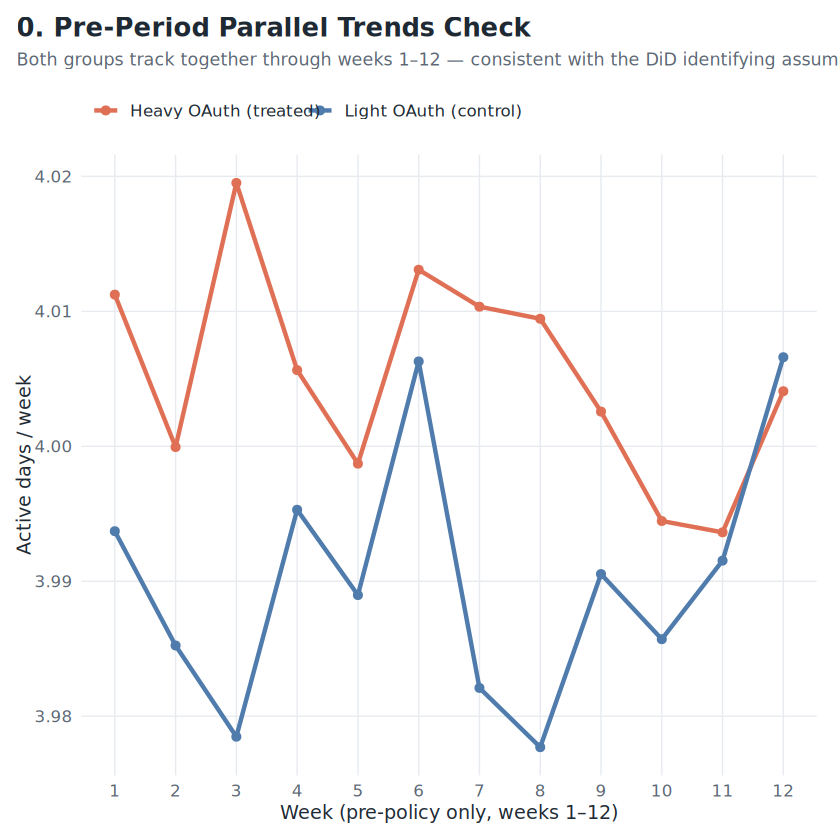

In [12]:
# Pre-period parallel trends visualization (all 12 pre-policy weeks)
pt_trends <- pre_policy |>
  group_by(week, oauth_heavy) |>
  summarise(avg_active = mean(active_days), .groups = "drop") |>
  mutate(group = factor(
    if_else(oauth_heavy, "Heavy OAuth (treated)", "Light OAuth (control)"),
    levels = c("Heavy OAuth (treated)", "Light OAuth (control)")
  ))

p_parallel <- pt_trends |>
  ggplot(aes(x = week, y = avg_active, color = group, group = group)) +
  geom_line(linewidth = 1.25) +
  geom_point(size = 2.1) +
  scale_color_manual(values = c(
    "Heavy OAuth (treated)" = "#E07055",
    "Light OAuth (control)" = "#4F7CAC"
  )) +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "0. Pre-Period Parallel Trends Check",
    subtitle = "Both groups track together through weeks 1–12 — consistent with the DiD identifying assumption",
    x = "Week (pre-policy only, weeks 1–12)",
    y = "Active days / week"
  ) +
  theme_bgl()

p_parallel


`geom_smooth()` using formula = 'y ~ x'


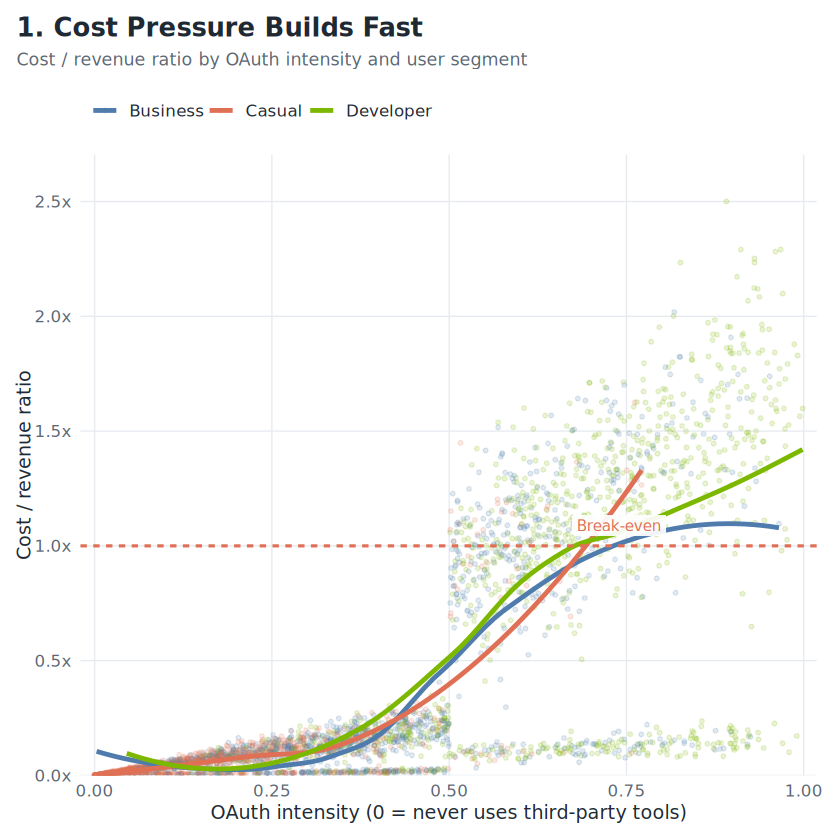

In [13]:
# Fig 1: cost pressure by user type
p1 <- users |>
  sample_n(3500) |>
  ggplot(aes(x = oauth_intensity_true, y = cost_revenue_ratio, color = segment)) +
  geom_point(alpha = 0.16, size = 1.0) +
  geom_smooth(method = "loess", se = FALSE, linewidth = 1.35, span = 0.85) +
  geom_hline(yintercept = 1, linetype = "22", color = bgl_cols["Churned"], linewidth = 0.9) +
  annotate(
    "label", x = 0.74, y = 1.09, label = "Break-even",
    fill = alpha("white", 0.92), linewidth = 0, color = bgl_cols["Churned"], size = 3.2
  ) +
  scale_color_manual(values = c(
    Developer = "#7DB800",
    Business = "#4F7CAC",
    Casual = "#E07055"
  )) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.25),
    labels = label_number(accuracy = 0.01),
    expand = expansion(mult = c(0.02, 0.02))
  ) +
  scale_y_continuous(
    breaks = seq(0, 2.5, 0.5),
    labels = label_number(accuracy = 0.1, suffix = "x"),
    expand = expansion(mult = c(0, 0.04))
  ) +
  coord_cartesian(ylim = c(0, 2.6)) +
  labs(
    title = "1. Cost Pressure Builds Fast",
    subtitle = "Cost / revenue ratio by OAuth intensity and user segment",
    x = "OAuth intensity (0 = never uses third-party tools)",
    y = "Cost / revenue ratio"
  ) +
  theme_bgl()

p1

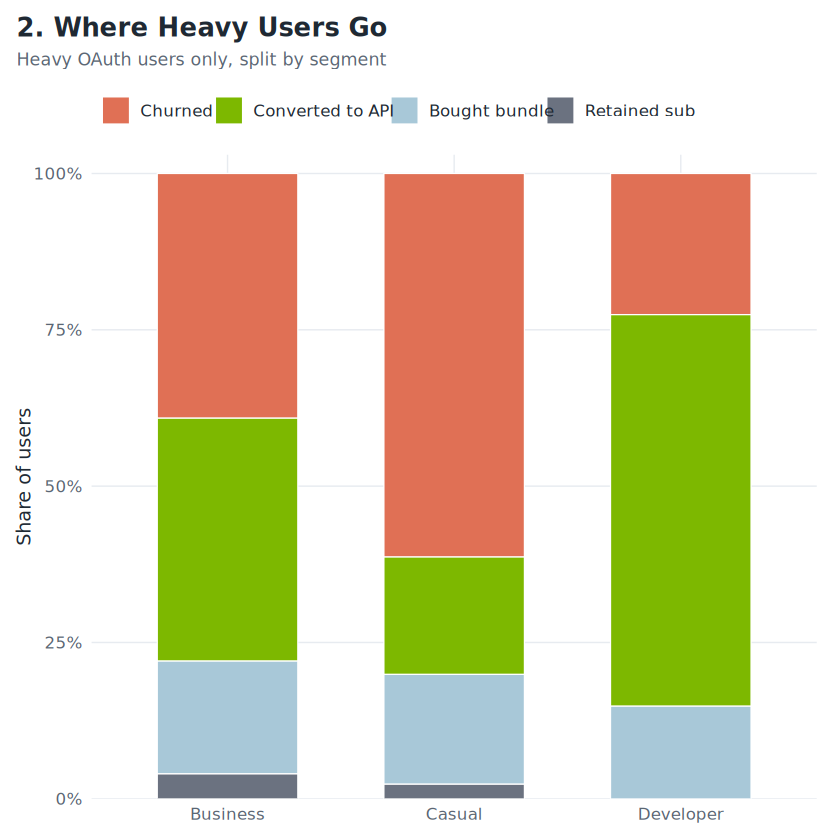

In [14]:
# Fig 2: post-policy destinations for heavy users
dest_data <- users |>
  filter(oauth_heavy) |>
  count(segment, post_status) |>
  group_by(segment) |>
  mutate(
    pct = n / sum(n),
    post_status = factor(post_status,
      levels = c("Churned", "Converted_API", "Bought_Bundle", "Retained_Sub")
    )
  )

p2 <- dest_data |>
  ggplot(aes(x = segment, y = pct, fill = post_status)) +
  geom_col(width = 0.62, color = "white", linewidth = 0.35) +
  scale_fill_manual(
    values = bgl_cols[c("Churned", "Converted_API", "Bought_Bundle", "Retained_Sub")],
    labels = c(
      Churned = "Churned",
      Converted_API = "Converted to API",
      Bought_Bundle = "Bought bundle",
      Retained_Sub = "Retained sub"
    )
  ) +
  scale_y_continuous(labels = label_percent(accuracy = 1), expand = expansion(mult = c(0, 0.03))) +
  labs(
    title = "2. Where Heavy Users Go",
    subtitle = "Heavy OAuth users only, split by segment",
    x = NULL,
    y = "Share of users"
  ) +
  theme_bgl()

p2

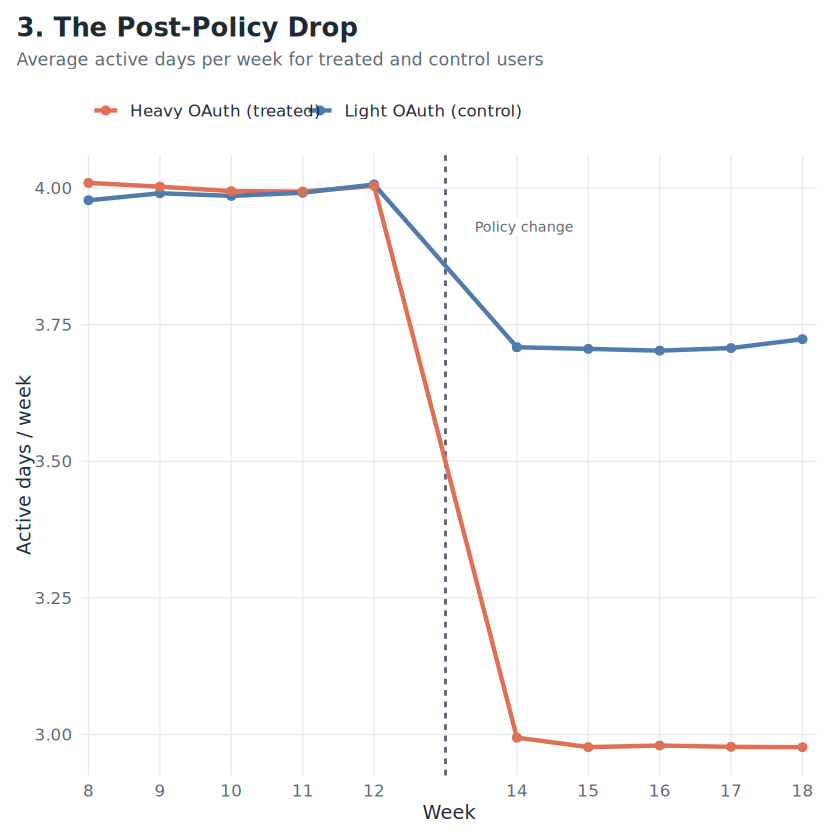

In [15]:
# Fig 3: DiD panel view
weekly_trends <- panel |>
  group_by(week, oauth_heavy) |>
  summarise(avg_active = mean(active_days), .groups = "drop") |>
  mutate(group = factor(
    if_else(oauth_heavy, "Heavy OAuth (treated)", "Light OAuth (control)"),
    levels = c("Heavy OAuth (treated)", "Light OAuth (control)")
  ))

p3 <- weekly_trends |>
  ggplot(aes(x = week, y = avg_active, color = group, group = group)) +
  geom_vline(xintercept = POLICY_WEEK, linetype = "22", color = bgl_cols["muted"], linewidth = 0.8) +
  geom_line(linewidth = 1.25) +
  geom_point(size = 2.1) +
  annotate(
    "label", x = 13.35, y = max(weekly_trends$avg_active) * 0.98,
    label = "Policy change", hjust = 0, size = 3.0,
    fill = alpha("white", 0.92), linewidth = 0, color = bgl_cols["muted"]
  ) +
  scale_color_manual(values = c(
    "Heavy OAuth (treated)" = "#E07055",
    "Light OAuth (control)" = "#4F7CAC"
  )) +
  scale_x_continuous(breaks = c(8:12, 14:18), expand = expansion(mult = c(0.01, 0.02))) +
  labs(
    title = "3. The Post-Policy Drop",
    subtitle = "Average active days per week for treated and control users",
    x = "Week",
    y = "Active days / week"
  ) +
  theme_bgl()

p3

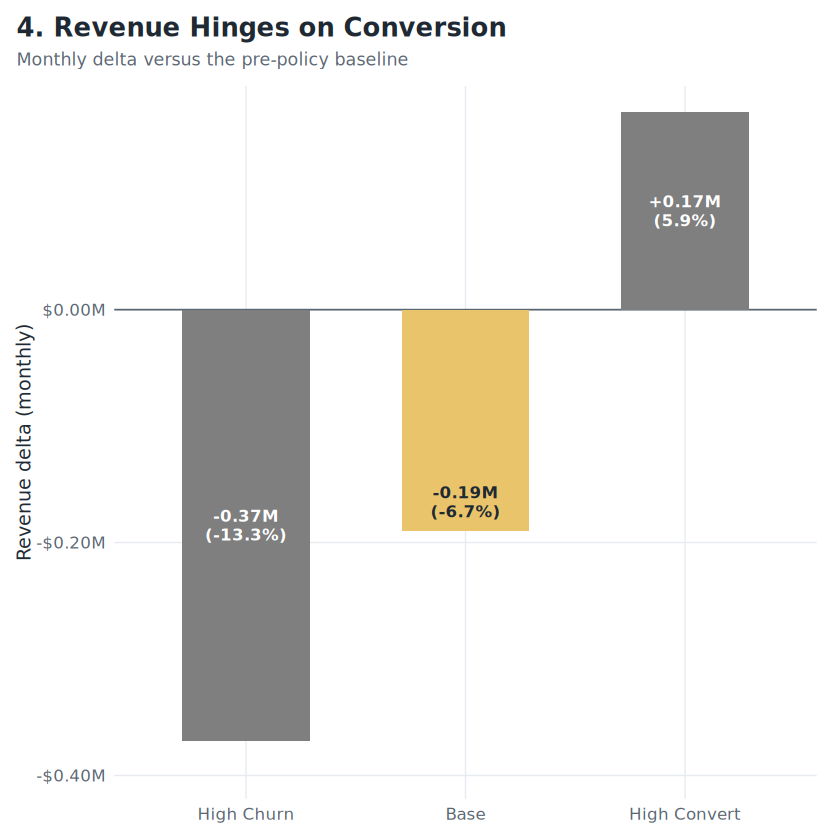

In [46]:
# Fig 4: scenario revenue sensitivity
p4_data <- scenarios |>
  mutate(
    Scenario = factor(
      Scenario,
      levels = c("High Churn", "Base", "High Convert")
    ),
    label = paste0(
      ifelse(`Rev Delta ($M)` >= 0, "+", ""),
      sprintf("%.2f", `Rev Delta ($M)`), "M\n(",
      sprintf("%.1f", `Rev Change (%)`), "%)"
    ),
    label_y = if_else(Scenario == "Base", `Rev Delta ($M)` + 0.025, `Rev Delta ($M)` / 2),
    label_color = if_else(Scenario == "Base", bgl_cols["ink"], "white")
  )

p4 <- p4_data |>
  ggplot(aes(x = Scenario, y = `Rev Delta ($M)`, fill = Scenario)) +
  geom_hline(yintercept = 0, color = bgl_cols["muted"], linewidth = 0.5) +
  geom_col(width = 0.58) +
  geom_text(
    aes(y = label_y, label = label, color = label_color),
    size = 3.5, fontface = "bold", lineheight = 0.95
  ) +
  scale_color_identity() +
  scale_fill_manual(values = c(
    "High Churn" = bgl_cols["Churned"],
    "Base" = "#E9C46A",
    "High Convert" = bgl_cols["Converted_API"]
  )) +
  scale_y_continuous(
    labels = label_dollar(accuracy = 0.01, suffix = "M"),
    limits = c(-0.42, 0.18),
    expand = expansion(mult = c(0, 0.02))
  ) +
  labs(
    title = "4. Revenue Hinges on Conversion",
    subtitle = "Monthly delta versus the pre-policy baseline",
    x = NULL,
    y = "Revenue delta (monthly)"
  ) +
  theme_bgl() +
  theme(legend.position = "none")

p4


In [47]:
# Save individual article figures
ggsave(file.path(output_dir, "00_parallel_trends.png"),
       p_parallel, width = 7.5, height = 5.2, dpi = 180, bg = "white")
ggsave(file.path(output_dir, "01_cost_revenue_ratio.png"),
       p1, width = 7.5, height = 5.2, dpi = 180, bg = "white")
ggsave(file.path(output_dir, "02_post_policy_destinations.png"),
       p2, width = 7.5, height = 5.2, dpi = 180, bg = "white")
ggsave(file.path(output_dir, "03_diff_in_diff.png"),
       p3, width = 7.5, height = 5.2, dpi = 180, bg = "white")
ggsave(file.path(output_dir, "04_scenario_revenue_impact.png"),
       p4, width = 7.5, height = 5.2, dpi = 180, bg = "white")

# Banner composite (p1 + p4)
banner_plot <- (p1 + theme(legend.position = "none")) | p4 +
  plot_annotation(
    title = "Anthropic's OAuth Policy Change",
    subtitle = "Synthetic unit economics and scenario modeling for heavy third-party users",
    theme = theme(
      plot.title = element_text(size = 16, face = "bold", colour = bgl_cols["ink"]),
      plot.subtitle = element_text(size = 10, color = bgl_cols["muted"])
    )
  )
ggsave(file.path(script_dir, "rate-limit-banner.png"),
       banner_plot, width = 12, height = 6, dpi = 180, bg = "white")

# Overview composite (all four)
combined_plot <- (p1 | p2) / (p3 | p4) +
  plot_annotation(
    title = "Anthropic OAuth Policy Change: Impact Analysis",
    subtitle = paste(
      "Synthetic data with true effects injected (P_churn=0.42, P_convert=0.40) and recovered via DiD.",
      "N=50,000 users. Policy change at week 13.",
      sep = "\n"
    ),
    theme = theme(
      plot.title = element_text(size = 15, face = "bold", colour = bgl_cols["ink"]),
      plot.subtitle = element_text(size = 9, color = bgl_cols["muted"])
    )
  )
ggsave(file.path(output_dir, "rate_limit_overview.png"),
       combined_plot, width = 14, height = 10, dpi = 150, bg = "white")

cat("===== ANALYSIS COMPLETE =====\n")
cat(sprintf("Figures saved to %s\n\n", output_dir))
cat("True effects injected into DGP:\n")
cat(sprintf("  P(Churn | Heavy OAuth):    %.2f\n", TRUE_CHURN_HEAVY))
cat(sprintf("  P(Convert | Heavy OAuth):  %.2f\n", TRUE_CONVERT_HEAVY))
cat(sprintf("  P(Bundle | Heavy OAuth):   %.2f\n", TRUE_BUNDLE_HEAVY))
cat("\nDiD estimator recovered from synthetic panel above.\n")
cat("Scenario table shows revenue sensitivity to conversion rate assumptions.\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


===== ANALYSIS COMPLETE =====
Figures saved to /workspaces/bouldergearlab/content/data-projects/rate-limit/figures

True effects injected into DGP:
  P(Churn | Heavy OAuth):    0.42
  P(Convert | Heavy OAuth):  0.40
  P(Bundle | Heavy OAuth):   0.18

DiD estimator recovered from synthetic panel above.
Scenario table shows revenue sensitivity to conversion rate assumptions.
